# Supplementary Figure S2: genomic coordinate balancing

**Purpose.** Recompute the variant-type AUROCs after balancing pathogenic and benign variants within 500 kbp genomic bins. The panel order follows Figure 1.

## Reproducibility contract

- **Run from:** the repository root.
- **Input:** `data/processed/clinvar_benchmark_updated.csv` (the complete scored benchmark; not stored in GitHub).
- **Outputs:** `results/tables/figure_s2_coordinate_balance_auroc.csv` and `results/figures/figure_s2.svg`.
- **Randomness:** deterministic downsampling and 1,000 stratified bootstrap replicates, seed 42.
- **Compute:** CPU; no model inference is performed.


## 1. Setup


In [1]:
from pathlib import Path
import pandas as pd

# Run this notebook from the repository root.
REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
MODEL_SCORE_DIR = DATA_DIR / "model_scores"
RESULTS_DIR = REPO_ROOT / "results"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"
SCORED_BENCHMARK_PATH = DATA_DIR / "processed" / "clinvar_benchmark_updated.csv"
RANDOM_SEED = 42

def read_table(path, required_columns=()):
    """Read a local table and verify that required columns are present."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}. See README.md.")
    frame = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(
        path, low_memory=False, dtype={"#CHROM": str}
    )
    missing = sorted(set(required_columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    return frame

def validate_output_files(paths):
    """Verify that every expected output was created and is not empty."""
    for value in paths:
        path = Path(value)
        if not path.exists() or path.stat().st_size == 0:
            raise RuntimeError(f"Expected output was not created: {path}")
    print(f"Validated {len(paths)} output file(s).")

HIGHER_IS_MORE_PATHOGENIC = {
    "PhyloP", "DNABERT2", "AlphaMissense", "PrimateAI_3D",
    "AlphaGenome_quantile", "Rule_based", "ntv3_post_log2fc_max",
}

DNA_MODEL_COLUMNS = [
    "PhyloP", "Evo2_7B", "Evo2_40B", "AlphaGenome_quantile", "Rule_based",
    "GPN_MSA", "PhyloGPN", "gpnstar_v_llr", "DNABERT2",
    "ntv3_pre_position_llr", "ntv3_post_log2fc_max",
]
ESM_MODEL_COLUMNS = ["ESM1b", "ESM1v", "ESM2", "vesm_score"]
MODEL_COLUMNS = DNA_MODEL_COLUMNS + ESM_MODEL_COLUMNS + ["AlphaMissense", "PrimateAI_3D"]

SUBGROUP_COLUMNS = [
    "group: 5'UTR", "group: missense", "group: noncoding",
    "group: RNA gene", "group: missense + intron (non-splice)",
    "group: intron (non-splice)", "group: synonymous",
    "group: missense + 3'UTR", "group: splice", "group: stop loss",
    "group: stop gain", "group: 3'UTR", "group: start loss",
]
PLOT_ORDER = [
    "Overall", "group: 5'UTR", "group: missense",
    "group: noncoding", "group: RNA gene", "group: missense + intron (non-splice)",
    "group: intron (non-splice)", "group: synonymous", "group: missense + 3'UTR",
    "group: splice", "group: stop loss", "group: stop gain",
    "group: 3'UTR", "group: start loss",
]
SUBGROUP_DISPLAY_NAMES = {
    "Overall": "All variants",
    "group: missense": "Missense", "group: missense + 3'UTR": "Missense & 3' UTR",
    "group: missense + intron (non-splice)": "Missense & Intron (Non-splice)",
    "group: stop gain": "Stop gain", "group: start loss": "Start loss",
    "group: noncoding": "Noncoding", "group: stop loss": "Stop loss",
    "group: synonymous": "Synonymous", "group: 5'UTR": "5' UTR",
    "group: 3'UTR": "3' UTR", "group: 3'UTR + RNA gene": "3' UTR + RNA gene",
    "group: splice": "Splice", "group: intron (non-splice)": "Intron (Non-splice)",
    "group: RNA gene": "RNA gene",
}
MODEL_DISPLAY_NAMES = {
    "PhyloP": "PhyloP", "Evo2_7B": "Evo2 7B", "Evo2_40B": "Evo2 40B",
    "AlphaGenome_quantile": "AlphaGenome", "Rule_based": "Rule-based",
    "GPN_MSA": "GPN-MSA", "PhyloGPN": "PhyloGPN", "gpnstar_v_llr": "GPN-Star",
    "DNABERT2": "DNABERT2", "ntv3_pre_position_llr": "NTv3-pre",
    "ntv3_post_log2fc_max": "NTv3-post", "ESM1b": "ESM1b", "ESM1v": "ESM1v",
    "ESM2": "ESM2", "vesm_score": "VESM++", "AlphaMissense": "AlphaMissense",
    "PrimateAI_3D": "PrimateAI-3D",
}

def models_for_subgroup(subgroup):
    if subgroup == "Overall":
        return DNA_MODEL_COLUMNS.copy()
    if subgroup in {
        "group: missense", "group: missense + 3'UTR",
        "group: missense + intron (non-splice)", "group: stop gain",
    }:
        return MODEL_COLUMNS.copy()
    if subgroup == "group: start loss":
        return DNA_MODEL_COLUMNS + ESM_MODEL_COLUMNS
    return DNA_MODEL_COLUMNS.copy()

def coordinate_balanced_sample(frame, bin_size=500_000, seed=RANDOM_SEED):
    """Downsample the majority class within each genomic coordinate bin."""
    work = frame.copy()
    work["_coordinate_bin"] = (
        work["#CHROM"].astype(str).str.replace("chr", "", regex=False)
        + ":" + (pd.to_numeric(work["POS"]) // bin_size).astype(str)
    )
    kept = []
    for _, bin_frame in work.groupby("_coordinate_bin", sort=True):
        classes = {
            int(label): group.index.to_numpy()
            for label, group in bin_frame.groupby("ClinVar_label")
        }
        if set(classes) != {0, 1}:
            continue
        size = min(len(classes[0]), len(classes[1]))
        # Match the submitted figure by restarting the seeded sampler for
        # each class within each coordinate bin.
        kept.extend([
            pd.Series(classes[0]).sample(n=size, replace=False, random_state=seed).to_numpy(),
            pd.Series(classes[1]).sample(n=size, replace=False, random_state=seed).to_numpy(),
        ])
    if not kept:
        return work.iloc[0:0].drop(columns="_coordinate_bin")
    return work.loc[np.concatenate(kept)].drop(columns="_coordinate_bin").sort_index()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_auc_score


FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load and balance input


In [2]:
data = read_table(SCORED_BENCHMARK_PATH, ["#CHROM", "POS", "ClinVar_label"] + SUBGROUP_COLUMNS)
balanced = coordinate_balanced_sample(data, bin_size=500_000, seed=RANDOM_SEED)
print(f"Balanced sample: {len(balanced):,} of {len(data):,} variants")


Balanced sample: 111,508 of 242,132 variants


## 3. Compute AUROC and confidence intervals


In [3]:
N_BOOTSTRAPS = 1_000


def bootstrap_auroc(labels, scores, n_boot=N_BOOTSTRAPS, seed=RANDOM_SEED):
    """Return AUROC and a stratified 95% bootstrap confidence interval."""
    labels = np.asarray(labels, dtype=int)
    scores = np.asarray(scores, dtype=float)
    estimate = roc_auc_score(labels, scores)
    rng = np.random.default_rng(seed)
    class_indices = [np.flatnonzero(labels == label) for label in (0, 1)]
    draws = []
    for _ in range(n_boot):
        index = np.concatenate([
            rng.choice(indices, size=len(indices), replace=True)
            for indices in class_indices
        ])
        draws.append(roc_auc_score(labels[index], scores[index]))
    low, high = np.percentile(draws, [2.5, 97.5])
    return float(estimate), float(low), float(high)


rows = []
for subgroup in PLOT_ORDER:
    subgroup_frame = balanced if subgroup == "Overall" else balanced[balanced[subgroup] == 1]
    models = [model for model in models_for_subgroup(subgroup) if model in subgroup_frame.columns]
    # Every model in a panel is evaluated on the same complete-case variants.
    work = subgroup_frame[["ClinVar_label"] + models].dropna()
    counts = work["ClinVar_label"].value_counts()
    n_benign = int(counts.get(0, 0))
    n_pathogenic = int(counts.get(1, 0))
    for model in models:
        if min(n_benign, n_pathogenic) == 0:
            continue
        score = work[model] if model in HIGHER_IS_MORE_PATHOGENIC else -work[model]
        estimate, low, high = bootstrap_auroc(work["ClinVar_label"], score)
        rows.append({
            "subgroup": subgroup,
            "model": model,
            "n": len(work),
            "n_benign": n_benign,
            "n_pathogenic": n_pathogenic,
            "pct_pathogenic": 100 * n_pathogenic / len(work),
            "auroc": estimate,
            "ci_low": low,
            "ci_high": high,
        })

results = pd.DataFrame(rows)
results.to_csv(TABLE_DIR / "figure_s2_coordinate_balance_auroc.csv", index=False)
results.head()


,subgroup,model,n,n_benign,n_pathogenic,pct_pathogenic,auroc,ci_low,ci_high
0,Overall,PhyloP,111269,55538,55731,50.086727,0.903827,0.902109,0.905724
1,Overall,Evo2_7B,111269,55538,55731,50.086727,0.971620,0.970732,0.972538
2,Overall,Evo2_40B,111269,55538,55731,50.086727,0.973501,0.972667,0.974410
3,Overall,AlphaGenome_quantile,111269,55538,55731,50.086727,0.692581,0.689411,0.695717
4,Overall,Rule_based,111269,55538,55731,50.086727,0.974721,0.973984,0.975434


## 4. Render the manuscript figure


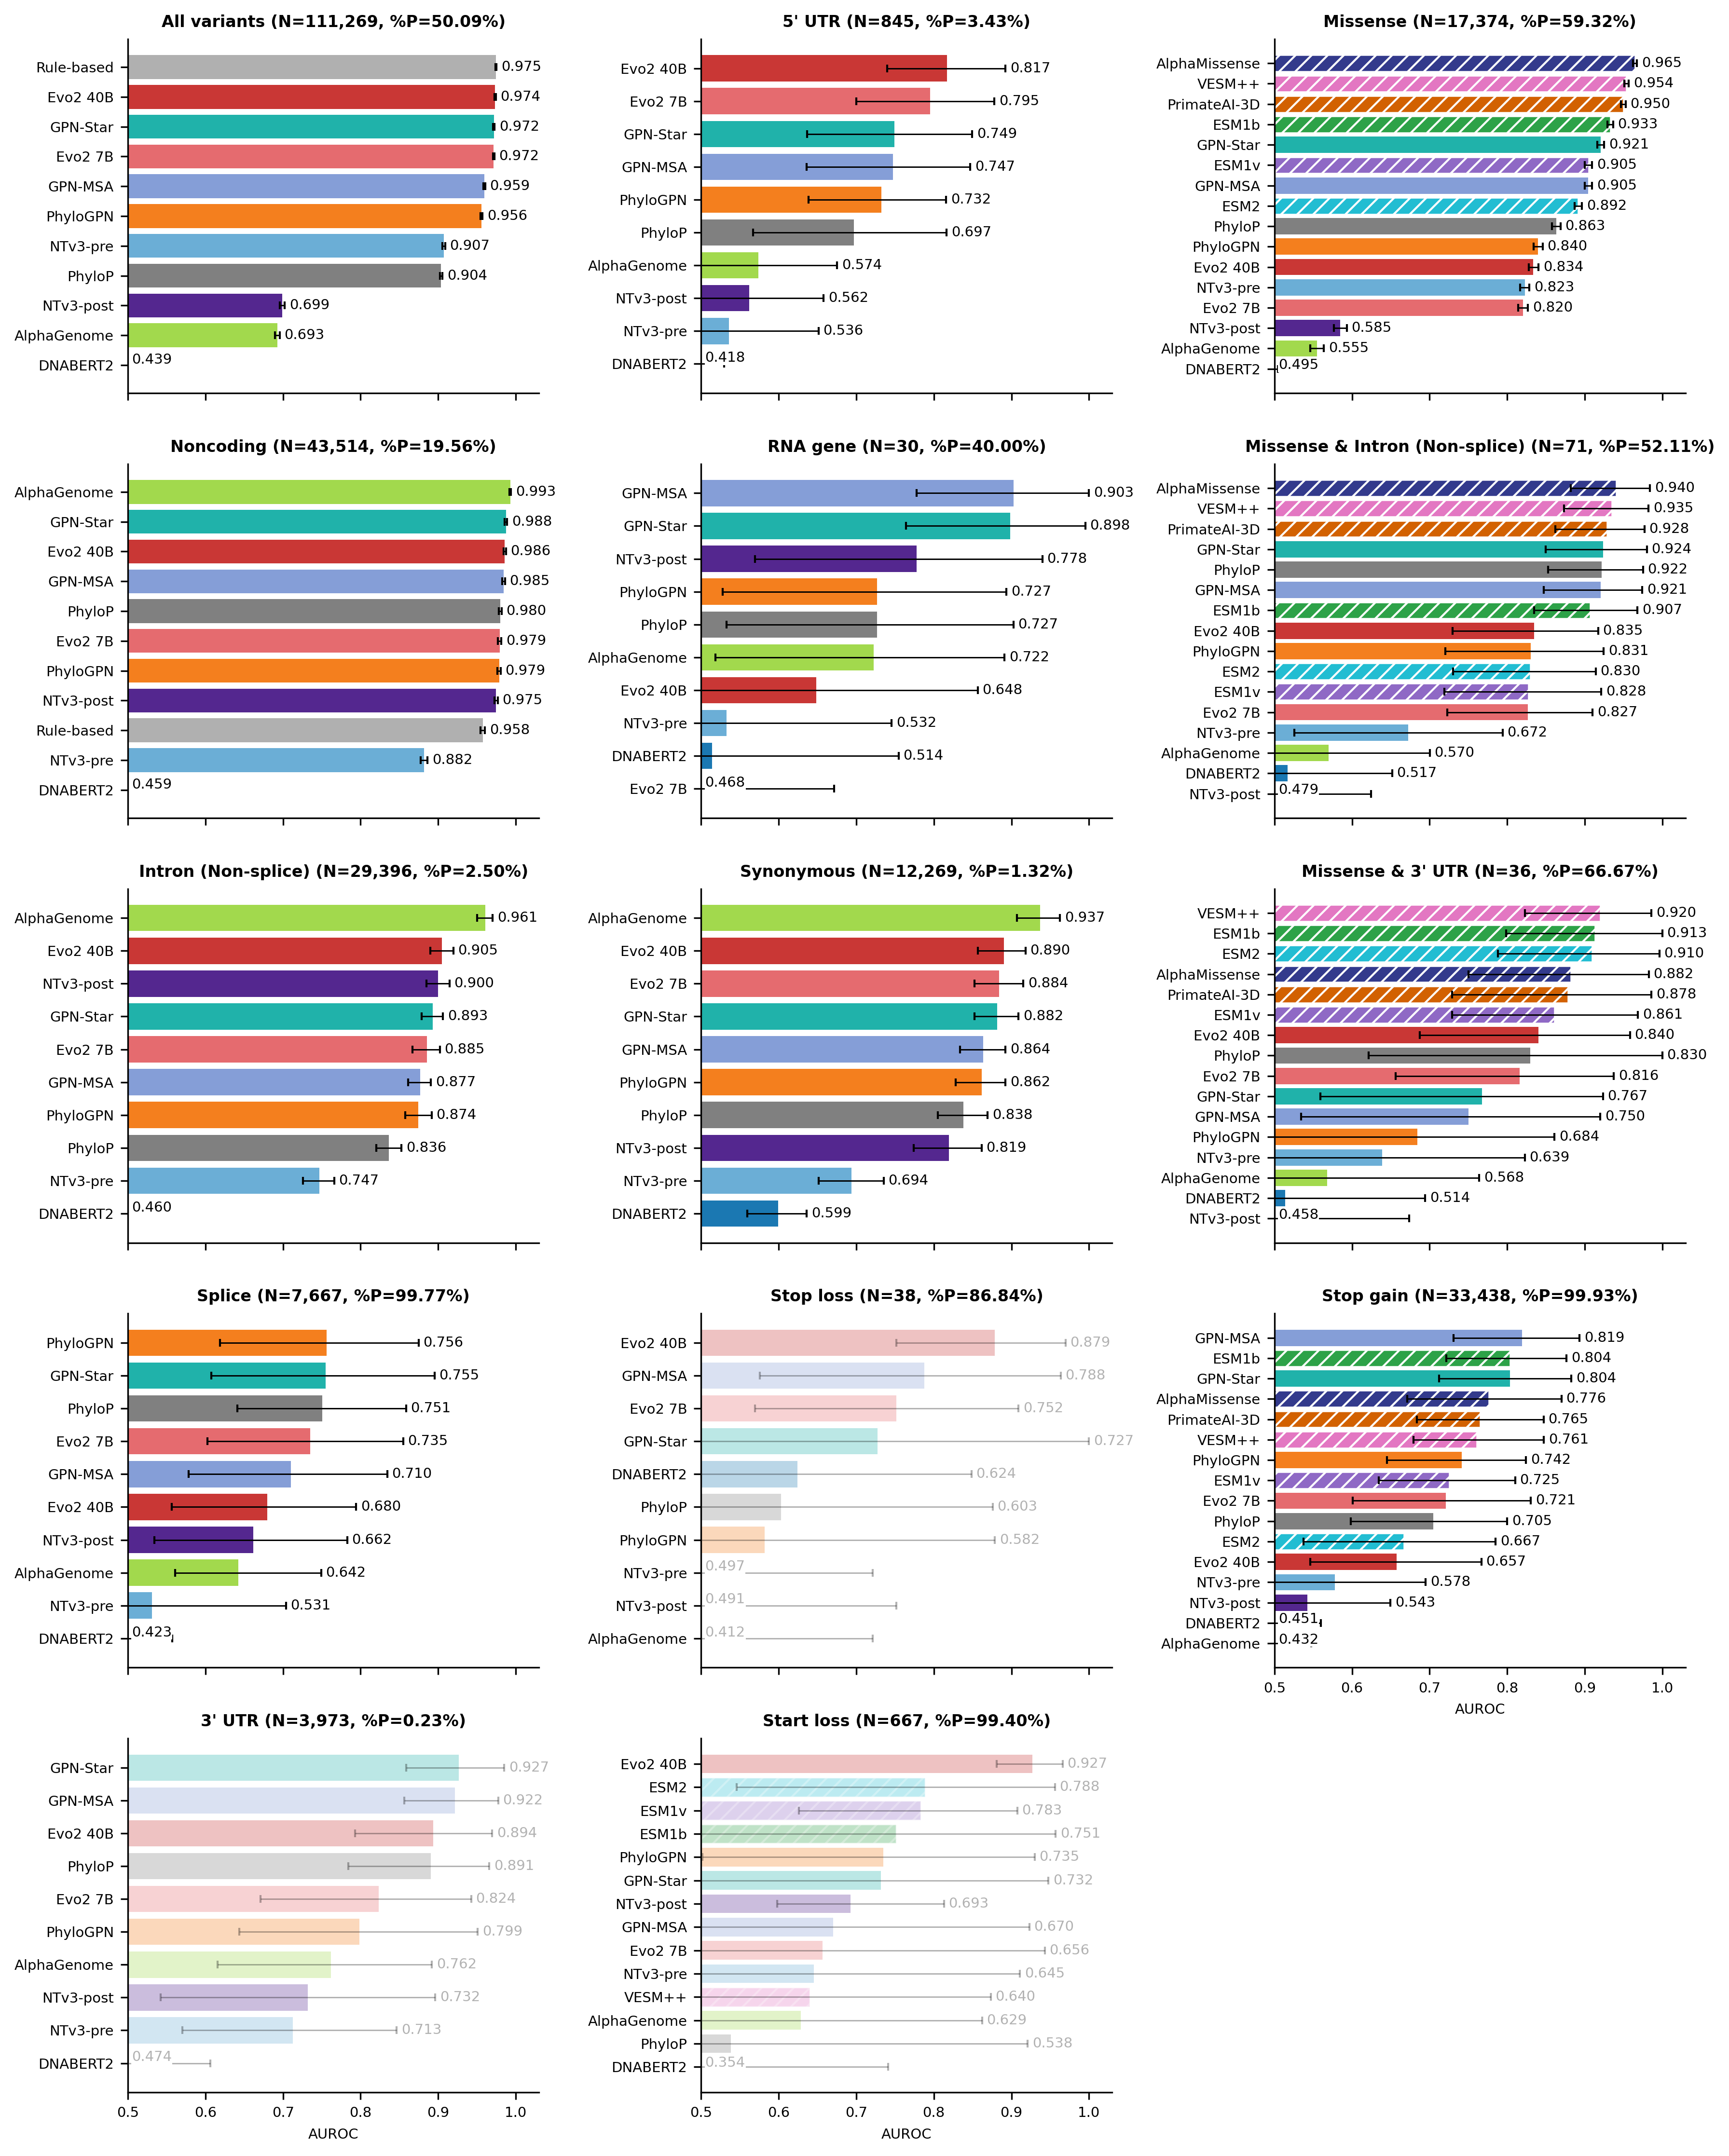

In [4]:
palette = {
    "PhyloP": "#808080", "Evo2_7B": "#e56b6f", "Evo2_40B": "#c93735",
    "AlphaGenome_quantile": "#a2d94d", "Rule_based": "#b0b0b0",
    "GPN_MSA": "#859ed7", "PhyloGPN": "#f47f1e", "gpnstar_v_llr": "#20b2aa",
    "DNABERT2": "#1b78b2", "ntv3_pre_position_llr": "#6baed6",
    "ntv3_post_log2fc_max": "#54278f", "ESM1b": "#2da248", "ESM1v": "#8f69c5",
    "ESM2": "#22bdd2", "vesm_score": "#e377c2", "AlphaMissense": "#333a8c",
    "PrimateAI_3D": "#d26101",
}
dashed_models = {"ESM1b", "ESM1v", "ESM2", "vesm_score", "AlphaMissense", "PrimateAI_3D"}

fig, axes = plt.subplots(5, 3, figsize=(12, 15), dpi=300)
axes = axes.flatten()
last_panel_by_column = {
    column: max(i for i in range(len(PLOT_ORDER)) if i % 3 == column)
    for column in range(3)
}

for i, (axis, subgroup) in enumerate(zip(axes, PLOT_ORDER)):
    panel = results[results["subgroup"] == subgroup].copy()
    if subgroup not in {"Overall", "group: noncoding"}:
        panel = panel[panel["model"] != "Rule_based"]
    panel = panel.sort_values("auroc")
    if panel.empty:
        axis.axis("off")
        continue

    unreliable = min(panel["n_benign"].iloc[0], panel["n_pathogenic"].iloc[0]) < 10
    alpha = 0.3 if unreliable else 1.0
    for y, row in enumerate(panel.itertuples()):
        hatch = "///" if row.model in dashed_models else None
        axis.barh(
            y, row.auroc, color=palette.get(row.model, "#777777"),
            hatch=hatch, edgecolor="white" if hatch else None,
            linewidth=0.6, alpha=alpha,
        )
        xerr_low = max(row.auroc - row.ci_low, 0.0)
        xerr_high = max(row.ci_high - row.auroc, 0.0)
        axis.errorbar(
            row.auroc, y, xerr=[[xerr_low], [xerr_high]], fmt="none",
            color="black", lw=0.7, capsize=2, alpha=alpha,
        )
        label_x = 0.505 if row.auroc < 0.5 else min(max(row.auroc, row.ci_high) + 0.006, 1.015)
        label_y = y + 0.18 if row.auroc < 0.5 else y
        text_box = dict(facecolor="white", edgecolor="none", pad=0.2) if row.auroc < 0.5 else None
        axis.text(
            label_x, label_y,
            f"{row.auroc:.3f}", va="center", ha="left", fontsize=7,
            alpha=alpha, bbox=text_box,
        )

    axis.set_yticks(
        range(len(panel)),
        [MODEL_DISPLAY_NAMES.get(model, model) for model in panel["model"]],
        fontsize=7,
    )
    n = int(panel["n"].iloc[0])
    pct = float(panel["pct_pathogenic"].iloc[0])
    axis.set_title(
        f"{SUBGROUP_DISPLAY_NAMES[subgroup]} (N={n:,}, %P={pct:.2f}%)",
        fontsize=8, fontweight="bold",
    )
    axis.set_xlim(0.5, 1.03)
    axis.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    show_x = i == last_panel_by_column[i % 3]
    axis.tick_params(axis="x", labelsize=7, labelbottom=show_x)
    if show_x:
        axis.set_xlabel("AUROC", fontsize=7)
    axis.spines[["top", "right"]].set_visible(False)

for axis in axes[len(PLOT_ORDER):]:
    axis.axis("off")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_s2.svg", format="svg", bbox_inches="tight")
plt.show()


## 5. Validate outputs


In [5]:

validate_output_files([
    TABLE_DIR / "figure_s2_coordinate_balance_auroc.csv",
    FIGURE_DIR / "figure_s2.svg",
])


Validated 2 output file(s).
